In [76]:
import torch
from pathlib import Path
from torchvision.datasets import CelebA

#for the query json
import json

#CLIP
from transformers import CLIPProcessor, CLIPModel
import numpy as np
from tqdm import tqdm

In [74]:
data_root = Path("dataset")

celeba_train = CelebA(root=data_root, split="train", download=False)
celeba_eval = CelebA(root=data_root, split="valid", download=False)
celeba_test = CelebA(root=data_root, split="test", download=False)
celeba_all = CelebA(root=data_root, split="all", download=False)

print(len(celeba_test))

19962


In [ ]:
#TESTING QUERYS
annotations_path = Path("celeba_evaluation.json")

with open(annotations_path, "r") as f:
    annotations = json.load(f)

len(annotations)
print(annotations[0])

{'query': '+Smiling', 'ground_truth': {'13': [325, 456, 579, 685, 763, 893, 981, 1363, 1646, 2142, 2747, 2812, 2979, 3318, 3325, 3536, 3637, 3932, 4361, 4452, 4549, 4569, 4678, 4780, 4831, 5112, 5208, 5448, 5533, 5926, 6127, 6153, 7595, 7798, 8151, 8342, 8440, 8592, 9009, 9452, 9506, 9612, 9685, 9881, 9930, 9968, 10367, 10719, 10915, 10968, 10973, 11813, 12361, 12673, 12695, 12788, 12934, 12986, 13060, 13141, 13731, 14215, 14323, 14848, 15058, 15422, 15953, 17205, 17384, 17638, 17748, 18096, 18202, 18221, 18290, 18446, 18503, 18799, 19046, 19179, 19800], '14': [235, 1787, 2806, 16035, 19731], '15': [155, 601, 967, 3303, 3611, 5051, 5248, 5607, 5872, 6091, 8132, 9439, 10308, 10343, 13366, 13967, 14185, 14498, 16595, 16639, 17342, 17990, 18393, 18499, 19334, 19623], '20': [4067, 7910, 10236, 12170, 15084, 15303, 17836, 18982], '23': [3532, 7167, 12990, 12991, 16198, 18702, 19482], '27': [8611, 8941, 9795, 10699, 13835, 16950, 17207, 17354, 17905, 18902], '28': [3581, 5557, 5834, 8124, 93

In [ ]:
idx2attribute = {idx: name for idx, name in enumerate(celeba_test.attr_names)} #there are only 40 attributes the 41st is '' 
attribute2idx = {name: idx for idx, name in enumerate(celeba_test.attr_names)}

print(attribute2idx)

{'5_o_Clock_Shadow': 0, 'Arched_Eyebrows': 1, 'Attractive': 2, 'Bags_Under_Eyes': 3, 'Bald': 4, 'Bangs': 5, 'Big_Lips': 6, 'Big_Nose': 7, 'Black_Hair': 8, 'Blond_Hair': 9, 'Blurry': 10, 'Brown_Hair': 11, 'Bushy_Eyebrows': 12, 'Chubby': 13, 'Double_Chin': 14, 'Eyeglasses': 15, 'Goatee': 16, 'Gray_Hair': 17, 'Heavy_Makeup': 18, 'High_Cheekbones': 19, 'Male': 20, 'Mouth_Slightly_Open': 21, 'Mustache': 22, 'Narrow_Eyes': 23, 'No_Beard': 24, 'Oval_Face': 25, 'Pale_Skin': 26, 'Pointy_Nose': 27, 'Receding_Hairline': 28, 'Rosy_Cheeks': 29, 'Sideburns': 30, 'Smiling': 31, 'Straight_Hair': 32, 'Wavy_Hair': 33, 'Wearing_Earrings': 34, 'Wearing_Hat': 35, 'Wearing_Lipstick': 36, 'Wearing_Necklace': 37, 'Wearing_Necktie': 38, 'Young': 39, '': 40}


(<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=178x218 at 0x7F20E67D23F0>, tensor([0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0]))
tensor([0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0])


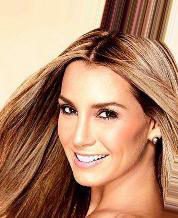

In [78]:
print(celeba_test[0])
print(celeba_test[0][1]) #tensor of attributes
celeba_all[0][0] #image


In [65]:
def match_number(query, dataset=celeba_train):   
    '''
    Takes a list of attributes (+Attr for present or -Attr for absent) and returns the number of images that satisfy the constraint.    
    '''
    considered_attributes = [] 
    matches = 0

    for element in query:
        if element[0] == '+':
            polarity = 1
        elif element[0] == '-':
            polarity = 0
        else:
            print("Query wrongly formulated")
            return 0
        considered_attributes.append([attribute2idx[element[1:]], polarity])
    
    for img in dataset:
        if all(img[1][attr_id] == polarity for attr_id, polarity in considered_attributes):
            matches += 1

    return matches

In [ ]:
match_number(['+5_o_Clock_Shadow', '+Arched_Eyebrows'], celeba_eval)

127

In [70]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")


In [ ]:
#CLIP example usage

image = celeba_eval[0][0] #PIL image
#IMAGES
inputs = processor(images=image, return_tensors="pt")
with torch.no_grad():
    image_features = model.get_image_features(**inputs) 
    print(image_features)

#TEXT
inputs = processor(text=["+Arched_Eyebrows", "+5_o_Clock_Shadow"], return_tensors="pt", padding=True)
with torch.no_grad():
    text_features = model.get_text_features(**inputs)
    print(image_features)


tensor([[ 5.2238e-01,  1.4376e-01, -2.9096e-01, -1.7204e-01,  6.2643e-02,
         -6.7434e-01, -3.6478e-01,  1.8895e-01,  3.2249e-01, -3.9301e-01,
          3.1883e-01,  9.4732e-02,  3.4201e-01, -1.3694e-01,  2.2489e-01,
          1.0017e-01,  1.6538e+00,  1.0602e-01, -1.3552e-01,  1.1933e-01,
         -1.5595e-01, -2.8317e-01,  5.0266e-01, -4.5392e-01, -8.5494e-02,
          2.6415e-01,  1.3271e-01, -4.7026e-01,  3.7114e-01,  3.4711e-01,
         -6.7321e-02,  5.6156e-01,  4.2775e-02,  8.2641e-02,  2.7391e-02,
          1.7577e-02,  1.3590e-05,  3.6770e-01,  5.5808e-01,  1.9924e+00,
         -1.9696e-01, -1.9455e-01,  1.1109e-01, -5.6389e-04,  3.6400e-01,
          9.2000e-01,  2.5746e-01, -2.5988e-01, -1.5135e-01,  1.1848e-01,
         -5.1160e-01,  1.8290e-01,  1.3267e-01, -4.6622e-01, -5.1067e-02,
         -5.8171e-02,  5.4269e-01,  1.9822e-01,  7.5996e-01, -1.4084e-02,
         -1.3488e-01, -3.6154e-01, -7.0224e-02,  2.8965e-01,  7.6781e-01,
         -3.5457e-02, -7.0315e-02, -8.

In [ ]:
#CREATION OF THE OFFLINE VISUAL FEATURE DATABASE

all_features = []

model.eval() #in order to avoid dropout and other training specific layers

#to save memory and speed up inference we disable gradient computation
with torch.no_grad(): 

    for idx in tqdm(range(len(celeba_all))):
        image = celeba_all[idx][0]

        inputs = processor(images=image, return_tensors="pt")

        inputs = {k: v.to(model.device) for k, v in inputs.items()} #move inputs to the same device as the model

        image_features = model.get_image_features(**inputs) 
        image_features = image_features / image_features.norm(dim=-1, keepdim=True) #normalize the features

        all_features.append(image_features.squeeze().cpu().numpy()) #move features to cpu and convert to numpy array

#use np.stack to convert the list of features and indices to a single numpy array, as it raises an error if the shapes don't match
all_features = np.stack(all_features)

np.save("celeba_visual_features.npz", features=all_features)

  0%|          | 194/202599 [00:35<10:09:56,  5.53it/s]


KeyboardInterrupt: 

In [ ]:
#RETRIEVAL EXAMPLE
data = np.load("celeba_visual_features.npz")
features = data["features"]
